# Feature Engineering + Embeddings
**Trump Posts vs S&P 500 — NLP Final Assignment**

### Structure
1. Imports, paths & config
2. Load preprocessed data
3. Tweet-level features
   - 3a. VADER sentiment
   - 3b. FinBERT sentiment
   - 3c. Topic discovery with BERTopic
   - 3d. Structural / stylistic features
   - 3e. Mentions & replies
4. Daily aggregation
5. Market-side feature engineering
6. Embeddings
   - 6a. Sentence embeddings
   - 6b. Semantic clustering (BERTopic)
   - 6c. Daily mean embeddings
   - 6d. Novelty score
   - 6e. UMAP visualisation
7. Final merge & save
8. Note on topic labelling

---
## 1 — Imports, Paths & Config

All paths and toggles live here. Nothing else in the notebook needs to be changed
when moving the project between machines.

In [12]:
from pathlib import Path
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine as cosine_distance
import umap
import time as _time_module
from datetime import time 


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("All imports are OK")

All imports are OK


In [4]:
import os
from pathlib import Path

# 1. Check if we are in Colab/Remote environment
if os.path.exists('/content'):
    repo_path = '/content/trump-tweets-nlp'
    # 2. Clone the repo into the cloud session if it's not there
    if not os.path.exists(repo_path):
        print("Cloning repo to Colab runtime...")
        !git clone https://github.com/deercarla/trump-tweets-nlp {repo_path}
    
    # 3. Move the terminal "into" the repo
    os.chdir(repo_path)
    print(f"Current working directory: {os.getcwd()}")

In [ ]:
#Paths
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "2_preprocessing" / "processed").exists():
            return p
    raise FileNotFoundError("Project root not found.")

PROJECT_ROOT  = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "2_preprocessing" / "processed"
OUTPUT_DIR    = PROJECT_ROOT / "3_feature_engineering" / "features"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#Toggles
FINBERT_ENABLED = True   # Set False to skip (saves ~10-20 min on CPU)
FINBERT_DEVICE  = -1     # -1 = CPU, 0 = first GPU
FINBERT_BATCH   = 64

EMB_MODEL_NAME  = "all-MiniLM-L6-v2"
EMB_BATCH_SIZE  = 128
NOVELTY_WINDOW  = 14     # days for rolling baseline
N_UMAP_PLOT     = 30_000 # subsample size for UMAP scatter plots

print("Project root:", PROJECT_ROOT)
print("Output dir  :", OUTPUT_DIR)

Project root: c:\Users\diogo\Desktop\CBS\YEAR 1\SEMESTER 2\NLP\Exam
Output dir  : c:\Users\diogo\Desktop\CBS\YEAR 1\SEMESTER 2\NLP\Exam\3_feature_engineering\features


---
## 2 — Load Preprocessed Data

In [6]:
tweets      = pd.read_pickle(PROCESSED_DIR / "tweets_processed.pkl")
daily_posts = pd.read_csv(PROCESSED_DIR / "daily_posts.csv",   parse_dates=["date"])
sp500       = pd.read_csv(PROCESSED_DIR / "sp500_aligned.csv", parse_dates=["date"])

print("tweets:     ", tweets.shape)
print("daily_posts:", daily_posts.shape)
print("sp500:      ", sp500.shape)
print("\nsp500 columns:", sp500.columns.tolist())

tweets:      (90551, 28)
daily_posts: (6094, 11)
sp500:       (4198, 10)

sp500 columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'simple_return_pct', 'log_return', 'next_simple_return_pct', 'next_log_return']


In [7]:
# Original posts only — exclude reposts to focus on Trump's own words
originals = tweets[tweets["repost_flag"] == False].copy()
originals = originals.reset_index(drop=True)

# Parse datetime and derive exact US Eastern time features
originals["date"] = pd.to_datetime(originals["date"], utc=True).dt.tz_convert("US/Eastern")
originals["date_only"] = originals["date"].dt.normalize().dt.tz_localize(None)

originals["time_et"] = originals["date"].dt.time
originals["hour_et"] = originals["date"].dt.hour
originals["minute_et"] = originals["date"].dt.minute
originals["weekday"] = originals["date"].dt.dayofweek

premarket_start = time(4, 0)
market_open = time(9, 30)
market_close = time(16, 0)

originals["is_premarket"] = (
    (originals["time_et"] >= premarket_start) &
    (originals["time_et"] < market_open)
).astype(int)

originals["is_market_hours"] = (
    (originals["time_et"] >= market_open) &
    (originals["time_et"] < market_close)
).astype(int)

originals["is_afterhours"] = (
    originals["time_et"] >= market_close
).astype(int)

print("Timing check:")
print(originals[["is_premarket", "is_market_hours", "is_afterhours"]].mean())

Timing check:
is_premarket      0.1607
is_market_hours   0.3896
is_afterhours     0.3953
dtype: float64


---
## 3a — VADER Sentiment

Rule-based model designed for social media text. Handles caps, punctuation and slang
without training data (Hutto & Gilbert, 2014). Outputs a compound score in [-1, +1].

In [9]:
vader = SentimentIntensityAnalyzer()

def get_vader_scores(text: str) -> dict:
    if not isinstance(text, str) or text.strip() == "":
        return {"vader_neg": np.nan, "vader_neu": np.nan,
                "vader_pos": np.nan, "vader_compound": np.nan}
    s = vader.polarity_scores(text)
    return {"vader_neg": s["neg"], "vader_neu": s["neu"],
            "vader_pos": s["pos"], "vader_compound": s["compound"]}

vader_df  = pd.DataFrame(list(originals["text"].apply(get_vader_scores)),
                         index=originals.index)
originals = pd.concat([originals, vader_df], axis=1)

def vader_label(c):
    if pd.isna(c):    return np.nan
    if c >= 0.05:     return "positive"
    if c <= -0.05:    return "negative"
    return "neutral"

originals["vader_label"] = originals["vader_compound"].apply(vader_label)

print("VADER label distribution:")
print(originals["vader_label"].value_counts())
originals[["text", "vader_compound", "vader_label"]].head()

VADER label distribution:
vader_label
positive    35460
neutral     22680
negative    16602
Name: count, dtype: int64


,text,vader_compound,vader_label
0,Be sure to tune in and watch Donald Trump on L...,0.5255,positive
1,Donald Trump will be appearing on The View tom...,0.7712,positive
2,Donald Trump reads Top Ten Financial Tips on L...,0.6468,positive
3,New Blog Post: Celebrity Apprentice Finale and...,0.0000,neutral
4,"""My persona will never be that of a wallflower...",0.0000,neutral


---
## 3b — FinBERT Sentiment

BERT fine-tuned on financial text (Araci, 2019). Better than VADER at understanding
words like "tariff" or "deficit" in context.

> Toggle `FINBERT_ENABLED = False` at the top to skip. Runtime: ~10-20 min on CPU.

In [10]:
if FINBERT_ENABLED:
    print("Loading FinBERT...")
    finbert_pipe = pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        tokenizer="ProsusAI/finbert",
        truncation=True, max_length=512,
        top_k=None, device=FINBERT_DEVICE,
    )
    texts = originals["text"].fillna("").tolist()
    all_results = []
    for i in range(0, len(texts), FINBERT_BATCH):
        all_results.extend(finbert_pipe(texts[i : i + FINBERT_BATCH]))
        if (i // FINBERT_BATCH) % 20 == 0:
            print(f"  {i:,} / {len(texts):,}")

    def parse_finbert(r):
        d = {x["label"]: x["score"] for x in r}
        return {"finbert_pos": d.get("positive", np.nan),
                "finbert_neg": d.get("negative", np.nan),
                "finbert_neu": d.get("neutral",  np.nan),
                "finbert_label": max(d, key=d.get),
                "finbert_polarity": d.get("positive", 0) - d.get("negative", 0)}

    finbert_df = pd.DataFrame([parse_finbert(r) for r in all_results],
                              index=originals.index)
    originals  = pd.concat([originals, finbert_df], axis=1)
    print("\nFinBERT label distribution:")
    print(originals["finbert_label"].value_counts())

else:
    print("FinBERT skipped.")
    for col in ["finbert_pos", "finbert_neg", "finbert_neu",
                "finbert_label", "finbert_polarity"]:
        originals[col] = np.nan

Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  0 / 74,742
  1,280 / 74,742
  2,560 / 74,742
  3,840 / 74,742
  5,120 / 74,742
  6,400 / 74,742
  7,680 / 74,742
  8,960 / 74,742
  10,240 / 74,742
  11,520 / 74,742
  12,800 / 74,742
  14,080 / 74,742
  15,360 / 74,742
  16,640 / 74,742
  17,920 / 74,742
  19,200 / 74,742
  20,480 / 74,742
  21,760 / 74,742
  23,040 / 74,742
  24,320 / 74,742
  25,600 / 74,742
  26,880 / 74,742
  28,160 / 74,742
  29,440 / 74,742
  30,720 / 74,742
  32,000 / 74,742
  33,280 / 74,742
  34,560 / 74,742
  35,840 / 74,742
  37,120 / 74,742
  38,400 / 74,742
  39,680 / 74,742
  40,960 / 74,742
  42,240 / 74,742
  43,520 / 74,742
  44,800 / 74,742
  46,080 / 74,742
  47,360 / 74,742
  48,640 / 74,742
  49,920 / 74,742
  51,200 / 74,742
  52,480 / 74,742
  53,760 / 74,742
  55,040 / 74,742
  56,320 / 74,742
  57,600 / 74,742
  58,880 / 74,742
  60,160 / 74,742
  61,440 / 74,742
  62,720 / 74,742
  64,000 / 74,742
  65,280 / 74,742
  66,560 / 74,742
  67,840 / 74,742
  69,120 / 74,742
  70,400 / 74,742
  71

---
## 3c — Topic Discovery with BERTopic

Instead of hand-crafted keyword lists, we use **BERTopic** (Grootendorst, 2022)
to discover topics directly from the data. BERTopic combines sentence embeddings,
UMAP dimensionality reduction, HDBSCAN clustering, and a class-based TF-IDF
(c-TF-IDF) to produce interpretable keyword summaries per topic — with no manual
keyword lists required.

We reuse the embeddings computed in Section 6a (cached to disk) to avoid
recomputing them here. Because BERTopic is run on the full corpus, the topic
assignments are available for feature engineering immediately after.

> **Runtime note:** BERTopic on 74k posts takes ~5–15 min on CPU depending on
> hardware. Set `BERTOPIC_CACHE` below — once computed, results are loaded from
> disk on subsequent runs.


In [10]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
import shutil

BERTOPIC_CACHE      = OUTPUT_DIR / "bertopic_model"
BERTOPIC_TOPICS_CSV = OUTPUT_DIR / "bertopic_topics.csv"

BERTOPIC_MIN_TOPIC_SIZE = 200
BERTOPIC_N_GRAM_RANGE   = (1, 2)
BERTOPIC_NR_TOPICS      = 15

#Always clear cache and refit
shutil.rmtree(BERTOPIC_CACHE, ignore_errors=True)
print("Cache cleared, fitting from scratch...")

#Load embeddings
EMBEDDING_CACHE = OUTPUT_DIR / "tweet_embeddings.npy"
if EMBEDDING_CACHE.exists():
    embeddings = np.load(EMBEDDING_CACHE)
    print(f"Loaded cached embeddings: {embeddings.shape}")
else:
    raise FileNotFoundError("Run Section 6a first.")

texts = originals["text_lemmatized"].fillna("").tolist()

#Fit
umap_model = UMAP(
    n_neighbors=15, n_components=5,
    min_dist=0.0, metric="cosine", random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=BERTOPIC_MIN_TOPIC_SIZE,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    n_gram_range=BERTOPIC_N_GRAM_RANGE,
    verbose=True,
)

topic_model.fit_transform(texts, embeddings)
print(f"Initial fit: {len(topic_model.get_topic_info()) - 1} topics found.")

#Reduce
topic_model.reduce_topics(texts, nr_topics=BERTOPIC_NR_TOPICS)
print(f"After reduction: {len(topic_model.get_topic_info()) - 1} topics.")

#Read assignments AFTER reduction
topics = topic_model.topics_

#Save
topic_model.save(str(BERTOPIC_CACHE))
print(f"Model saved to {BERTOPIC_CACHE}")

#Attach to originals
originals["bertopic_id"]    = topics
originals["bertopic_label"] = originals["bertopic_id"].map(
    lambda t: "outlier" if t == -1 else f"topic_{t}"
)

n_topics   = len(set(topics)) - (1 if -1 in topics else 0)
n_outliers = sum(1 for t in topics if t == -1)
print(f"\nFinal topic count : {n_topics}")
print(f"Outliers (topic -1): {n_outliers:,} ({100*n_outliers/len(topics):.1f}%)")
print(originals["bertopic_label"].value_counts().head(20))

Cache cleared, fitting from scratch...
Loaded cached embeddings: (74742, 384)


2026-05-11 19:40:20,874 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-11 19:46:14,500 - BERTopic - Dimensionality - Completed ✓
2026-05-11 19:46:14,559 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 19:46:25,554 - BERTopic - Cluster - Completed ✓
2026-05-11 19:46:25,626 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 19:46:29,452 - BERTopic - Representation - Completed ✓
2026-05-11 19:46:30,168 - BERTopic - Topic reduction - Reducing number of topics
2026-05-11 19:46:30,242 - BERTopic - Representation - Fine-tuning topics using representation models.


Initial fit: 47 topics found.


2026-05-11 19:46:33,711 - BERTopic - Representation - Completed ✓
2026-05-11 19:46:33,729 - BERTopic - Topic reduction - Reduced number of topics from 48 to 15
2026-05-11 19:46:33,990 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


After reduction: 14 topics.
Model saved to c:\Users\diogo\Desktop\CBS\YEAR 1\SEMESTER 2\NLP\Exam\3_feature_engineering\features\bertopic_model

Final topic count : 14
Outliers (topic -1): 23,710 (31.7%)
bertopic_label
outlier     23710
topic_0     14782
topic_1     14470
topic_2      5046
topic_3      3241
topic_4      3031
topic_5      2570
topic_6      1724
topic_7      1668
topic_8      1458
topic_9      1426
topic_10      624
topic_11      446
topic_12      282
topic_13      264
Name: count, dtype: int64


Top 14 topics by size:

 Topic  Count                                                    Name
     0  13848                                0_trump_thanks_great_run
     1   7778                              1_biden_election_fake_news
     2   6681                               2_rt_rt rt_trump_rt thank
     3   5786                            3_great_border_thank_america
     4   4745                   4_image_image image_video_video image
     5   2732                          5_thank_great_thank thank_true
     6   2165                               6_china_tariff_iran_trade
     7   2015                             7_obamacare_tax_job_economy
     8   1749                  8_think_entrepreneur_success_think big
     9   1368 9_endorsement_total endorsement_complete total_complete
    10    646                                10_nfl_game_player_great
    11    436                               11_book_new book_copy_new
    12    292                   12_wind_turbine_wind turbine_scotl

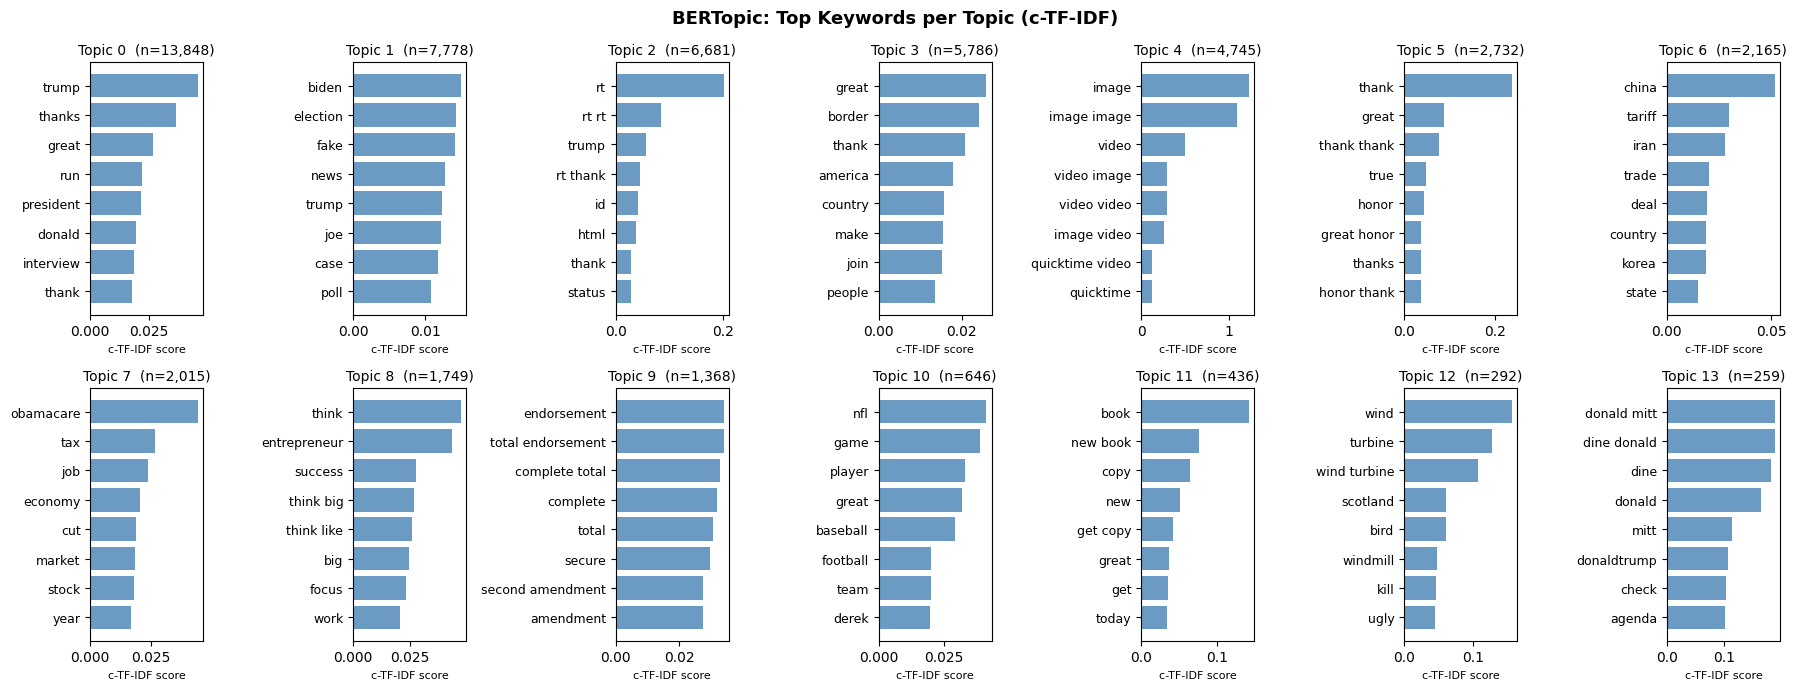

In [ ]:
#Topic overview
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1]  # exclude outlier topic

print(f"Top {min(20, len(topic_info))} topics by size:\n")
print(topic_info[["Topic", "Count", "Name"]].head(20).to_string(index=False))

# Save topic info to CSV for the report
topic_info.to_csv(BERTOPIC_TOPICS_CSV, index=False)
print(f"\nSaved topic info to {BERTOPIC_TOPICS_CSV}")

#Visualise top keywords per topic (bar chart)
N_SHOW = 14   # number of topics to plot
fig, axes = plt.subplots(2, N_SHOW // 2, figsize=(18, 7))

for ax, (topic_id, _) in zip(axes.flat,
                               topic_info.head(N_SHOW).iterrows()):
    t_id  = topic_info.iloc[list(topic_info.index).index(topic_id)]["Topic"]
    words = topic_model.get_topic(t_id)
    if not words:
        continue
    terms, scores = zip(*words[:8])
    ax.barh(range(len(terms)), scores, color="steelblue", alpha=0.8)
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"Topic {t_id}  (n={topic_info[topic_info['Topic']==t_id]['Count'].values[0]:,})",
                 fontsize=10)
    ax.set_xlabel("c-TF-IDF score", fontsize=8)

plt.suptitle("BERTopic: Top Keywords per Topic (c-TF-IDF)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bertopic_keywords.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
#Binary topic flags from BERTopic
BERTOPIC_THEME_MAP = {
    0:  "topic_trump_identity",
    1:  "topic_elections",
    2:  "rt_noise",  
    3:  "topic_rallies_nationalism",
    4:  "image_noise", 
    5:  "topic_praise_thanks",
    6:  "topic_trade_geopolitics",
    7:  "topic_economy_markets",
    8:  "topic_motivational_business",
    9:  "topic_endorsements",
    10: "topic_sports",
    11: "topic_book_promotion",
    12: "topic_energy_environment",
    13: "topic_mitt_dinner"
}

# Create binary flag columns
for topic_id, flag_name in BERTOPIC_THEME_MAP.items():
    originals[flag_name] = (originals["bertopic_id"] == topic_id).astype(int)

topic_flag_cols = list(BERTOPIC_THEME_MAP.values())

if topic_flag_cols:
    print("Topic flag counts:")
    print(originals[topic_flag_cols].sum().sort_values(ascending=False))
else:
    print("No themes mapped yet — inspect the keyword chart above and fill in BERTOPIC_THEME_MAP.")
    print("\nBERTopic topic distribution (for reference):")
    print(originals["bertopic_label"].value_counts().head(20))


Topic flag counts:
topic_trump_identity           13848
topic_elections                 7778
topic_rallies_nationalism       5786
topic_praise_thanks             2732
topic_trade_geopolitics         2165
topic_economy_markets           2015
topic_motivational_business     1749
topic_endorsements              1368
topic_sports                     646
topic_book_promotion             436
topic_energy_environment         292
dtype: int64


---
## 3d — Structural / Stylistic Features

In [ ]:
def caps_ratio(text: str) -> float:
    if not isinstance(text, str): return np.nan
    alpha = [c for c in text if c.isalpha()]
    return sum(1 for c in alpha if c.isupper()) / len(alpha) if alpha else 0.0

originals["caps_ratio"]        = originals["text"].apply(caps_ratio)
originals["exclamation_count"] = originals["text"].str.count(r"!")
originals["question_count"]    = originals["text"].str.count(r"\?")
originals["url_flag"]          = originals["text"].str.contains(r"http[s]?://", na=False).astype(int)
originals["log_engagement"]    = np.log1p(
    originals["favorite_count"].fillna(0) + originals["repost_count"].fillna(0)
)

# Timing flags (US Eastern)
originals["is_premarket"] = (
    (originals["time_et"] >= time(4, 0)) &
    (originals["time_et"] <  time(9, 30))
).astype(int)

originals["is_afterhours"] = (
    originals["time_et"] >= time(16, 0)
).astype(int)

originals["is_market_hours"] = (
    (originals["time_et"] >= time(9, 30)) &
    (originals["time_et"] <  time(16, 0))
).astype(int)

print("Structural features added.")
originals[["caps_ratio", "exclamation_count", "log_engagement",
           "is_premarket", "is_market_hours", "is_afterhours"]].describe()

Structural features added.


,caps_ratio,exclamation_count,log_engagement,is_premarket,is_market_hours,is_afterhours
count,74742.0000,74742.0000,74742.0000,74742.0000,74742.0000,74742.0000
mean,0.1366,0.6767,7.8104,0.1890,0.4152,0.3953
std,0.1734,0.9498,3.2440,0.3915,0.4928,0.4889
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0526,0.0000,4.7005,0.0000,0.0000,0.0000
50%,0.0882,0.0000,9.1145,0.0000,0.0000,0.0000
75%,0.1625,1.0000,10.4872,0.0000,1.0000,1.0000
max,1.0000,19.0000,14.6191,1.0000,1.0000,1.0000


---
## 3e — Mentions & Replies

Extracts all `@handles` mentioned in each tweet into a list column,
and flags whether the post is a reply to another user.

In [ ]:
def extract_mentions(text: str) -> list:
    if not isinstance(text, str): return []
    return [m.lower() for m in re.findall(r"@(\w+)", text)]

originals["mentions_list"]  = originals["text"].apply(extract_mentions)
originals["mentions_count"] = originals["mentions_list"].apply(len)
originals["has_mention"]    = (originals["mentions_count"] > 0).astype(int)

# Reply flag: use in_reply_to column if available, else detect @handle at start
if "in_reply_to" in originals.columns:
    originals["is_reply"] = originals["in_reply_to"].notna().astype(int)
else:
    originals["is_reply"] = originals["text"].str.match(r"^\s*@\w+", na=False).astype(int)

# Sanity check: top mentioned accounts
all_mentions = [m for lst in originals["mentions_list"] for m in lst]
print("Top 20 most mentioned accounts:")
for handle, count in Counter(all_mentions).most_common(20):
    print(f"  @{handle:<25} {count:,}")

print(f"\nTweets with a mention : {originals['has_mention'].sum():,}")
print(f"Reply tweets          : {originals['is_reply'].sum():,}")

Top 20 most mentioned accounts:
  @realdonaldtrump           8,789
  @foxnews                   893
  @barackobama               811
  @foxandfriends             690
  @apprenticenbc             426
  @cnn                       397
  @mittromney                358
  @seanhannity               254
  @ivankatrump               213
  @nytimes                   203
  @breitbartnews             171
  @megynkelly                161
  @whitehouse                147
  @oreillyfactor             145
  @celebapprentice           144
  @newsmax                   143
  @macys                     139
  @trumpdoral                132
  @nbc                       128
  @rsbn                      127

Tweets with a mention : 24,562
Reply tweets          : 3,589


---
## 4 — Daily Aggregation

In [ ]:
def daily_agg(df: pd.DataFrame, suffix: str = "") -> pd.DataFrame:
    
    # Detect which topic flag columns exist on the dataframe
    topic_cols = [c for c in df.columns if c.startswith("topic_")]
    
    agg = df.groupby("date_only").agg(
        post_count       = ("text",             "count"),
        vader_mean       = ("vader_compound",   "mean"),
        vader_std        = ("vader_compound",   "std"),
        vader_max_pos    = ("vader_compound",   "max"),
        vader_max_neg    = ("vader_compound",   "min"),
        finbert_mean     = ("finbert_polarity", "mean"),
        finbert_std      = ("finbert_polarity", "std"),
        caps_ratio_mean  = ("caps_ratio",       "mean"),
        exclamation_mean = ("exclamation_count","mean"),
        exclamation_max  = ("exclamation_count","max"),
        max_engagement   = ("log_engagement",   "max"),
        mean_word_count  = ("word_count",       "mean"),
        mention_count    = ("mentions_count",   "sum"),
        reply_count      = ("is_reply",         "sum"),
        **{t: (t, "max") for t in topic_cols},
    ).reset_index()
    
    agg["date_only"] = pd.to_datetime(agg["date_only"])
    if suffix:
        agg = agg.rename(columns={c: f"{c}{suffix}"
                                   for c in agg.columns if c != "date_only"})
    return agg

daily_all = daily_agg(originals)
daily_pre = daily_agg(originals[originals["is_premarket"] == 1], suffix="_premarket")
daily_features = daily_all.merge(daily_pre, on="date_only", how="left")
print("Daily features shape:", daily_features.shape)
daily_features.head()

Daily features shape: (4867, 59)


,date_only,post_count,vader_mean,vader_std,vader_max_pos,vader_max_neg,finbert_mean,finbert_std,caps_ratio_mean,exclamation_mean,exclamation_max,max_engagement,mean_word_count,mention_count,reply_count,topic_elections,topic_rallies_campaign,topic_praise_thanks,topic_motivational,topic_media_attacks,topic_legal,topic_trump_identity,topic_rallies_nationalism,topic_trade_geopolitics,topic_economy_markets,topic_motivational_business,topic_endorsements,topic_sports,topic_book_promotion,topic_energy_environment,post_count_premarket,vader_mean_premarket,vader_std_premarket,vader_max_pos_premarket,vader_max_neg_premarket,finbert_mean_premarket,finbert_std_premarket,caps_ratio_mean_premarket,exclamation_mean_premarket,exclamation_max_premarket,max_engagement_premarket,mean_word_count_premarket,mention_count_premarket,reply_count_premarket,topic_elections_premarket,topic_rallies_campaign_premarket,topic_praise_thanks_premarket,topic_motivational_premarket,topic_media_attacks_premarket,topic_legal_premarket,topic_trump_identity_premarket,topic_rallies_nationalism_premarket,topic_trade_geopolitics_premarket,topic_economy_markets_premarket,topic_motivational_business_premarket,topic_endorsements_premarket,topic_sports_premarket,topic_book_promotion_premarket,topic_energy_environment_premarket
0,2009-05-04,2,0.6483,0.1737,0.7712,0.5255,0.0418,0.0046,0.0991,1.0000,1,7.2786,22.5000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-05-08,2,0.3234,0.4574,0.6468,0.0000,0.0508,0.0177,0.1200,0.5000,1,3.8918,15.0000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1.0000,0.6468,NaN,0.6468,0.6468,0.0383,NaN,0.1196,1.0000,1.0000,3.8918,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,2009-05-12,2,0.2404,0.3400,0.4809,0.0000,-0.1093,0.1675,0.0847,0.0000,0,8.0864,20.5000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-05-13,1,0.7506,NaN,0.7506,0.7506,0.0848,NaN,0.0778,0.0000,0,3.4657,16.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-05-14,1,0.2023,NaN,0.2023,0.2023,0.0137,NaN,0.0500,0.0000,0,3.7377,14.0000,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Rolling sentiment windows & momentum
daily_features = daily_features.sort_values("date_only").reset_index(drop=True)

daily_features["vader_3d_rolling"] = daily_features["vader_mean"].rolling(3,  min_periods=1).mean()
daily_features["vader_7d_rolling"] = daily_features["vader_mean"].rolling(7,  min_periods=1).mean()
daily_features["vader_momentum"]   = daily_features["vader_mean"] - daily_features["vader_3d_rolling"]

print("Rolling features added.")
daily_features[["date_only", "vader_mean", "vader_3d_rolling",
                "vader_7d_rolling", "vader_momentum"]].head()

Rolling features added.


,date_only,vader_mean,vader_3d_rolling,vader_7d_rolling,vader_momentum
0,2009-05-04,0.6483,0.6483,0.6483,0.0000
1,2009-05-08,0.3234,0.4859,0.4859,-0.1625
2,2009-05-12,0.2404,0.4041,0.4041,-0.1636
3,2009-05-13,0.7506,0.4382,0.4907,0.3125
4,2009-05-14,0.2023,0.3978,0.4330,-0.1955


---
## 5 — Market-Side Feature Engineering

The S&P CSV already has `daily_return`, `abs_return` and
`next_day_return` pre-computed. We rename them and add lagged returns and
rolling volatility.

In [ ]:
sp = sp500.sort_values("date").copy()

# Standardize market column names
sp = sp.rename(columns={
    "close": "Close",
    "high": "High",
    "low": "Low",
    "open": "Open",
    "volume": "Volume",
})

# Build returns explicitly instead of renaming simple returns into log returns
if "log_return" not in sp.columns:
    sp["log_return"] = np.log(sp["Close"] / sp["Close"].shift(1))

if "next_log_return" not in sp.columns:
    sp["next_log_return"] = sp["log_return"].shift(-1)

sp["abs_return"] = sp["log_return"].abs()
sp["market_up"] = (sp["log_return"] > 0).astype(int)
sp["next_market_up"] = (sp["next_log_return"] > 0).astype(int)

sp["return_lag1"] = sp["log_return"].shift(1)
sp["return_lag2"] = sp["log_return"].shift(2)

sp["vol_5d"] = sp["log_return"].rolling(5).std()
sp["vol_20d"] = sp["log_return"].rolling(20).std()

# Lagged versions for premarket models to avoid same-day leakage
sp["vol_5d_lag1"] = sp["vol_5d"].shift(1)
sp["vol_20d_lag1"] = sp["vol_20d"].shift(1)

sp["date_only"] = pd.to_datetime(sp["date"]).dt.normalize()

print("Market features computed.")
display(sp[[
    "date", "Close", "log_return", "market_up",
    "next_log_return", "next_market_up",
    "return_lag1", "vol_5d", "vol_5d_lag1", "vol_20d", "vol_20d_lag1"
]].head(50))

Market features computed.


,date,Close,log_return,market_up,next_log_return,next_market_up,return_lag1,vol_5d,vol_5d_lag1,vol_20d,vol_20d_lag1
0,2009-05-04,907.2400,0.0333,1,-0.0038,0,NaN,NaN,NaN,NaN,NaN
1,2009-05-05,903.8000,-0.0038,0,0.0173,1,0.0333,NaN,NaN,NaN,NaN
2,2009-05-06,919.5300,0.0173,1,-0.0133,0,-0.0038,NaN,NaN,NaN,NaN
3,2009-05-07,907.3900,-0.0133,0,0.0238,1,0.0173,NaN,NaN,NaN,NaN
4,2009-05-08,929.2300,0.0238,1,-0.0217,0,-0.0133,0.0194,NaN,NaN,NaN
5,2009-05-11,909.2400,-0.0217,0,-0.0010,0,0.0238,0.0195,0.0194,NaN,NaN
6,2009-05-12,908.3500,-0.0010,0,-0.0273,0,-0.0217,0.0194,0.0195,NaN,NaN
7,2009-05-13,883.9200,-0.0273,0,0.0103,1,-0.0010,0.0203,0.0194,NaN,NaN
8,2009-05-14,893.0700,0.0103,1,-0.0115,0,-0.0273,0.0214,0.0203,NaN,NaN
9,2009-05-15,882.8800,-0.0115,0,0.0299,1,0.0103,0.0153,0.0214,NaN,NaN


---
## 6 — Embeddings

Dense vector representations add three things on top of VADER/FinBERT:
1. **Data-driven topic discovery** via clustering
2. **Daily mean embedding** as a model feature
3. **Novelty score** — how unusual is today's posting vs the recent baseline?

### 6a — Sentence Embeddings

`all-MiniLM-L6-v2`: 384 dimensions, fast on CPU, great for semantic similarity.
Embeddings are cached — re-running this cell is instant after the first run.

> Runtime: ~5-15 min on CPU for 74k tweets.

In [9]:
EMBEDDING_CACHE = OUTPUT_DIR / "tweet_embeddings.npy"
texts = originals["text"].fillna("").tolist()

if EMBEDDING_CACHE.exists():
    print(f"Loading cached embeddings...")
    embeddings = np.load(EMBEDDING_CACHE)
else:
    print(f"Computing embeddings with '{EMB_MODEL_NAME}'...")
    emb_model  = SentenceTransformer(EMB_MODEL_NAME)
    embeddings = emb_model.encode(
        texts, batch_size=EMB_BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,  # unit-norm: cosine sim = dot product
        convert_to_numpy=True,
    )
    np.save(EMBEDDING_CACHE, embeddings)
    print(f"Saved to {EMBEDDING_CACHE}")

print(f"Embeddings: {embeddings.shape}  ({embeddings.nbytes/1e6:.1f} MB)")

Computing embeddings with 'all-MiniLM-L6-v2'...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/584 [00:00<?, ?it/s]

Saved to c:\Users\diogo\Desktop\CBS\YEAR 1\SEMESTER 2\NLP\Exam\3_feature_engineering\features\tweet_embeddings.npy
Embeddings: (74742, 384)  (114.8 MB)


### 6b — Semantic Clustering with BERTopic

BERTopic was already fitted in Section 3c using these same embeddings.
Here we attach the topic assignments to the originals dataframe for UMAP
visualisation and derive the `dominant_topic` daily feature.

Topic IDs and their keyword summaries are available via `topic_model.get_topic_info()`.
The `cluster_label` column is populated from `bertopic_label` for compatibility
with the rest of the pipeline.


In [ ]:
# Use BERTopic assignments as the cluster column (replaces K-Means)
# This keeps downstream code (daily aggregation, UMAP colouring) compatible.

originals["cluster_kmeans"] = originals["bertopic_id"]
originals["cluster_label"]  = originals["bertopic_label"]

# Save cluster centres placeholder (not used by BERTopic but keeps save cell happy)
# We save the BERTopic topic vectors instead
topic_ids = [t for t in topic_model.get_topic_info()["Topic"] if t != -1]
topic_vectors = np.array([
    np.mean([vec for _, vec in topic_model.get_topic(t)], axis=0)
    if topic_model.get_topic(t) else np.zeros(1)
    for t in topic_ids
])

print("Cluster label distribution (BERTopic topics):")
print(originals["cluster_label"].value_counts().head(20))


Cluster label distribution (BERTopic topics):
cluster_label
outlier     24242
topic_0     13848
topic_1      7778
topic_2      6681
topic_3      5786
topic_4      4745
topic_5      2732
topic_6      2165
topic_7      2015
topic_8      1749
topic_9      1368
topic_10      646
topic_11      436
topic_12      292
topic_13      259
Name: count, dtype: int64


### 6c — Daily Mean Embeddings

Average all tweet embeddings per day into one 384-dim vector.
Also compute within-day diversity (std) — high = Trump posted about many different things.

In [ ]:
daily_emb_rows = []
for date, group in originals.groupby("date_only"):
    embs     = embeddings[group["emb_idx"].values]
    mean_emb = embs.mean(axis=0)
    row = {"date_only": date,
           "emb_diversity":   embs.std(axis=0).mean(),
           "dominant_cluster": group["cluster_label"].mode()[0]}
    for dim, val in enumerate(mean_emb):
        row[f"emb_{dim}"] = val
    daily_emb_rows.append(row)

daily_embeddings = pd.DataFrame(daily_emb_rows)
daily_embeddings["date_only"] = pd.to_datetime(daily_embeddings["date_only"])

emb_cols   = [c for c in daily_embeddings.columns
              if c.startswith("emb_") and c != "emb_diversity"]
emb_matrix = daily_embeddings[emb_cols].values

print(f"Daily embedding matrix: {emb_matrix.shape}")

Daily embedding matrix: (4867, 384)


### 6d — Novelty Score

Cosine distance between today's mean embedding and the 7, 14 and 30-day rolling baseline.
High score = Trump is posting about something semantically unusual,
which may have stronger market impact than routine posts.

Loaded 4,867 daily embeddings of dimension 384

Window comparison — stability of novelty scores:
Window         Mean      Std  Autocorr(1)
------------------------------------------
  7-day:     0.2432   0.1452       0.4939
  14-day:     0.2312   0.1418       0.4663
  30-day:     0.2261   0.1399       0.4553


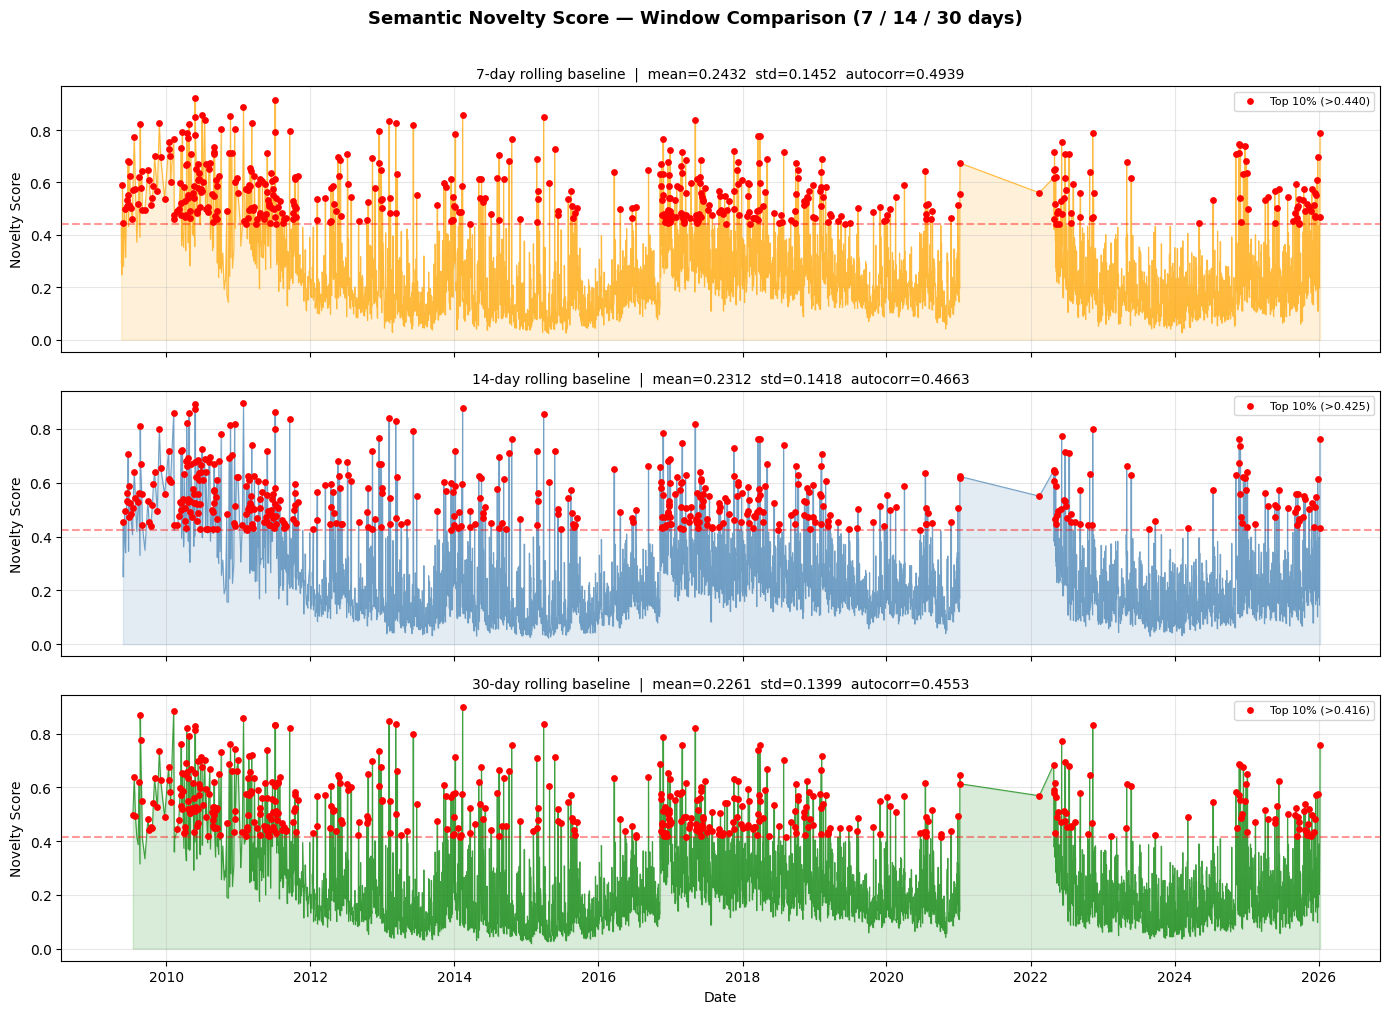

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance
import matplotlib.pyplot as plt
from pathlib import Path

#Load daily mean embeddings and dates
OUTPUT_DIR = Path(r"C:\Dev\nlp-final-project\3_feature_engineering\features")

emb_matrix = np.load(OUTPUT_DIR / "daily_mean_embeddings.npy")  # (4867, 384)
dates_df   = pd.read_csv(OUTPUT_DIR / "daily_mean_embeddings_dates.csv",
                         parse_dates=["date_only"])

assert len(emb_matrix) == len(dates_df), "Mismatch between embeddings and dates!"
print(f"Loaded {len(emb_matrix):,} daily embeddings of dimension {emb_matrix.shape[1]}")

emb_matrix_sorted = emb_matrix
dates             = dates_df["date_only"].values

#Novelty computation
def compute_novelty(emb_matrix, window):
    scores = [np.nan] * window
    for i in range(window, len(emb_matrix)):
        baseline = emb_matrix[i - window:i].mean(axis=0)
        scores.append(cosine_distance(emb_matrix[i], baseline))
    return scores

#Compute and compare all three windows
windows = [7, 14, 30]
results = {}
print("\nWindow comparison — stability of novelty scores:")
print(f"{'Window':<10} {'Mean':>8} {'Std':>8} {'Autocorr(1)':>12}")
print("-" * 42)
for w in windows:
    scores    = compute_novelty(emb_matrix_sorted, w)
    s         = pd.Series(scores).dropna()
    results[w] = scores
    print(f"  {w}-day:   {s.mean():>8.4f} {s.std():>8.4f} {s.autocorr():>12.4f}")

#Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = {7: "orange", 14: "steelblue", 30: "green"}

for ax, w in zip(axes, windows):
    s = pd.Series(results[w], index=dates)
    ax.plot(s.index, s.values, lw=0.8, color=colors[w], alpha=0.7)
    ax.fill_between(s.index, s.values, alpha=0.15, color=colors[w])

    threshold = s.quantile(0.9)
    high      = s[s >= threshold]
    ax.scatter(high.index, high.values,
               color="red", s=15, zorder=5, label=f"Top 10% (>{threshold:.3f})")
    ax.axhline(threshold, color="red", ls="--", alpha=0.4)

    ax.set_ylabel("Novelty Score")
    ax.set_title(f"{w}-day rolling baseline  |  "
                 f"mean={s.mean():.4f}  std={s.std():.4f}  "
                 f"autocorr={s.autocorr():.4f}",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Semantic Novelty Score — Window Comparison (7 / 14 / 30 days)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "novelty_window_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 6e — UMAP Visualisation

Projects 384 dimensions → 2D. Three plots:
1. Coloured by cluster — validates semantic coherence
2. Coloured by next-day S&P return — the key EDA plot
3. Coloured by platform (X vs Truth Social)

> Runtime: ~5-10 min for 74k points. Cached after first run.

In [ ]:
# Load saved tweet features so this section can be rerun independently
from pathlib import Path
import pandas as pd
import numpy as np

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path.cwd() / "3_feature_engineering" / "features"

originals = pd.read_pickle(OUTPUT_DIR / "tweets_features.pkl")
originals["date"] = pd.to_datetime(originals["date"], utc=True).dt.tz_convert("US/Eastern")
originals["date_only"] = originals["date"].dt.normalize().dt.tz_localize(None)

if (OUTPUT_DIR / "tweet_embeddings.npy").exists():
    embeddings = np.load(OUTPUT_DIR / "tweet_embeddings.npy")
    print(f"Loaded cached embeddings: {embeddings.shape}")
else:
    print("Warning: tweet_embeddings.npy not found. UMAP and any embedding-based plots may fail.")

print(f"Loaded originals: {len(originals):,} rows")

Loaded cached embeddings: (74742, 384)
Loaded originals: 74,742 rows


In [ ]:
UMAP_CACHE = OUTPUT_DIR / "umap_2d.npy"

if UMAP_CACHE.exists():
    print("Loading cached UMAP projection...")
    umap_2d = np.load(UMAP_CACHE)
else:
    print("Fitting UMAP...")
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        metric="cosine", random_state=42, verbose=True)
    umap_2d = reducer.fit_transform(embeddings)
    np.save(UMAP_CACHE, umap_2d)

originals["umap_x"] = umap_2d[:, 0]
originals["umap_y"] = umap_2d[:, 1]
print(f"UMAP shape: {umap_2d.shape}")

Loading cached UMAP projection...
UMAP shape: (74742, 2)


In [ ]:
# Reload originals and label mapping so this plot can be rerun independently
from pathlib import Path
import pandas as pd

try:
    OUTPUT_DIR
except NameError:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "3_feature_engineering" / "features").exists():
        if PROJECT_ROOT.parent == PROJECT_ROOT:
            raise FileNotFoundError("Project root not found")
        PROJECT_ROOT = PROJECT_ROOT.parent
    OUTPUT_DIR = PROJECT_ROOT / "3_feature_engineering" / "features"

originals = pd.read_pickle(OUTPUT_DIR / "tweets_features.pkl")
originals["date"] = pd.to_datetime(originals["date"], utc=True).dt.tz_convert("US/Eastern")
originals["date_only"] = originals["date"].dt.normalize().dt.tz_localize(None)

BERTOPIC_THEME_MAP = {
    0:  "topic_trump_identity",
    1:  "topic_elections",
    2:  "rt_noise",
    3:  "topic_rallies_nationalism",
    4:  "image_noise",
    5:  "topic_praise_thanks",
    6:  "topic_trade_geopolitics",
    7:  "topic_economy_markets",
    8:  "topic_motivational_business",
    9:  "topic_endorsements",
    10: "topic_sports",
    11: "topic_book_promotion",
    12: "topic_energy_environment",
    13: "topic_mitt_dinner"
}

label_lookup = {
    tid: name.replace("topic_", "").replace("_", " ").title()
    for tid, name in BERTOPIC_THEME_MAP.items()
}

if (OUTPUT_DIR / "tweet_embeddings.npy").exists():
    embeddings = np.load(OUTPUT_DIR / "tweet_embeddings.npy")
    print(f"Loaded embeddings: {embeddings.shape}")
else:
    print("Warning: tweet_embeddings.npy not found.")

print(f"Loaded originals: {len(originals):,} rows")

Loaded embeddings: (74742, 384)
Loaded originals: 74,742 rows


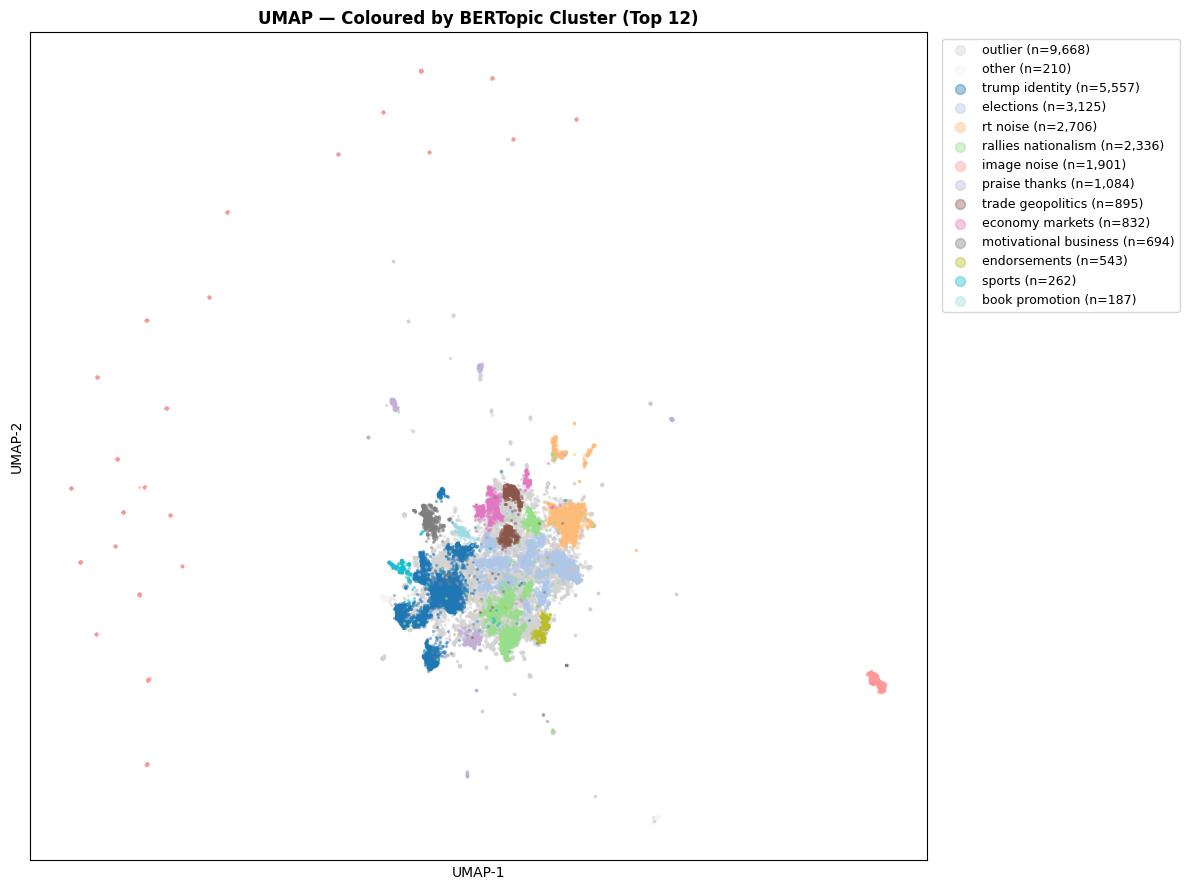

In [ ]:
# Plot 1 — by cluster
plot_df = originals.sample(min(N_UMAP_PLOT, len(originals)), random_state=42)
unique_c = sorted(plot_df["cluster_kmeans"].unique())
cmap = plt.get_cmap("tab20", len(unique_c))

# Build label lookup from BERTOPIC_THEME_MAP, fall back to topic ID for unmapped ones
label_lookup = {tid: name.replace("topic_", "").replace("_", " ")
                for tid, name in BERTOPIC_THEME_MAP.items()}
# Only colour the top N largest topics, collapse the rest to "other"
TOP_N = 12

top_topic_ids = set(
    originals[originals["bertopic_id"] != -1]["bertopic_id"]
    .value_counts().head(TOP_N).index
)

plot_df = originals.sample(min(N_UMAP_PLOT, len(originals)), random_state=42).copy()
plot_df["plot_label"] = plot_df["bertopic_id"].apply(
    lambda t: "outlier" if t == -1
    else label_lookup.get(t, f"topic_{t}") if t in top_topic_ids
    else "other"
)

unique_labels = ["outlier", "other"] + [
    label_lookup.get(t, f"topic_{t}") for t in
    sorted(top_topic_ids, key=lambda t: -originals[originals["bertopic_id"]==t].shape[0])
]

cmap = plt.get_cmap("tab20", TOP_N)
color_map = {"outlier": "lightgrey", "other": "whitesmoke"}
color_map.update({label_lookup.get(t, f"topic_{t}"): cmap(i)
                  for i, t in enumerate(sorted(top_topic_ids))})

fig, ax = plt.subplots(figsize=(12, 9))
for label in unique_labels:
    sub = plot_df[plot_df["plot_label"] == label]
    if len(sub) == 0:
        continue
    ax.scatter(sub["umap_x"], sub["umap_y"], s=2, alpha=0.4,
               color=color_map.get(label, "grey"),
               label=f"{label} (n={len(sub):,})", rasterized=True)

ax.legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_title("UMAP — Coloured by BERTopic Cluster (Top 12)", fontweight="bold")
ax.set(xlabel="UMAP-1", ylabel="UMAP-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

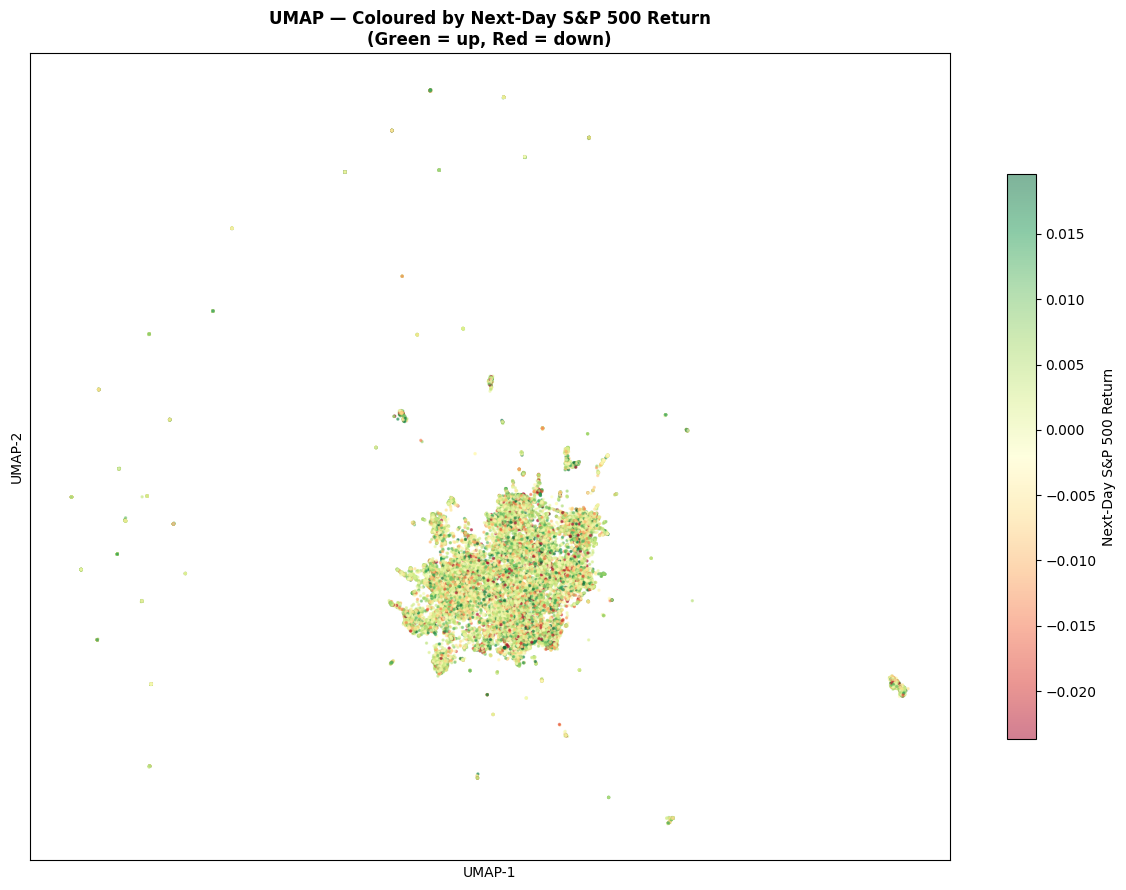

In [ ]:
# Plot 2 — by next-day S&P return
sp_lookup = sp[["date_only", "next_log_return"]].copy()

# Both sides are already tz-naive at this point
originals_plot = originals.merge(sp_lookup, on="date_only", how="left").dropna(subset=["next_log_return"])
plot_df2 = originals_plot.sample(min(N_UMAP_PLOT, len(originals_plot)), random_state=42)

ret = plot_df2["next_log_return"].clip(
    plot_df2["next_log_return"].quantile(0.02),
    plot_df2["next_log_return"].quantile(0.98),
)

fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(plot_df2["umap_x"], plot_df2["umap_y"],
                c=ret, cmap="RdYlGn", s=2, alpha=0.5, rasterized=True,
                vmin=ret.min(), vmax=ret.max())
plt.colorbar(sc, ax=ax, shrink=0.7).set_label("Next-Day S&P 500 Return", fontsize=10)
ax.set_title("UMAP — Coloured by Next-Day S&P 500 Return\n"
             "(Green = up, Red = down)", fontweight="bold")
ax.set(xlabel="UMAP-1", ylabel="UMAP-2"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_by_return.png", dpi=150, bbox_inches="tight")
plt.show()

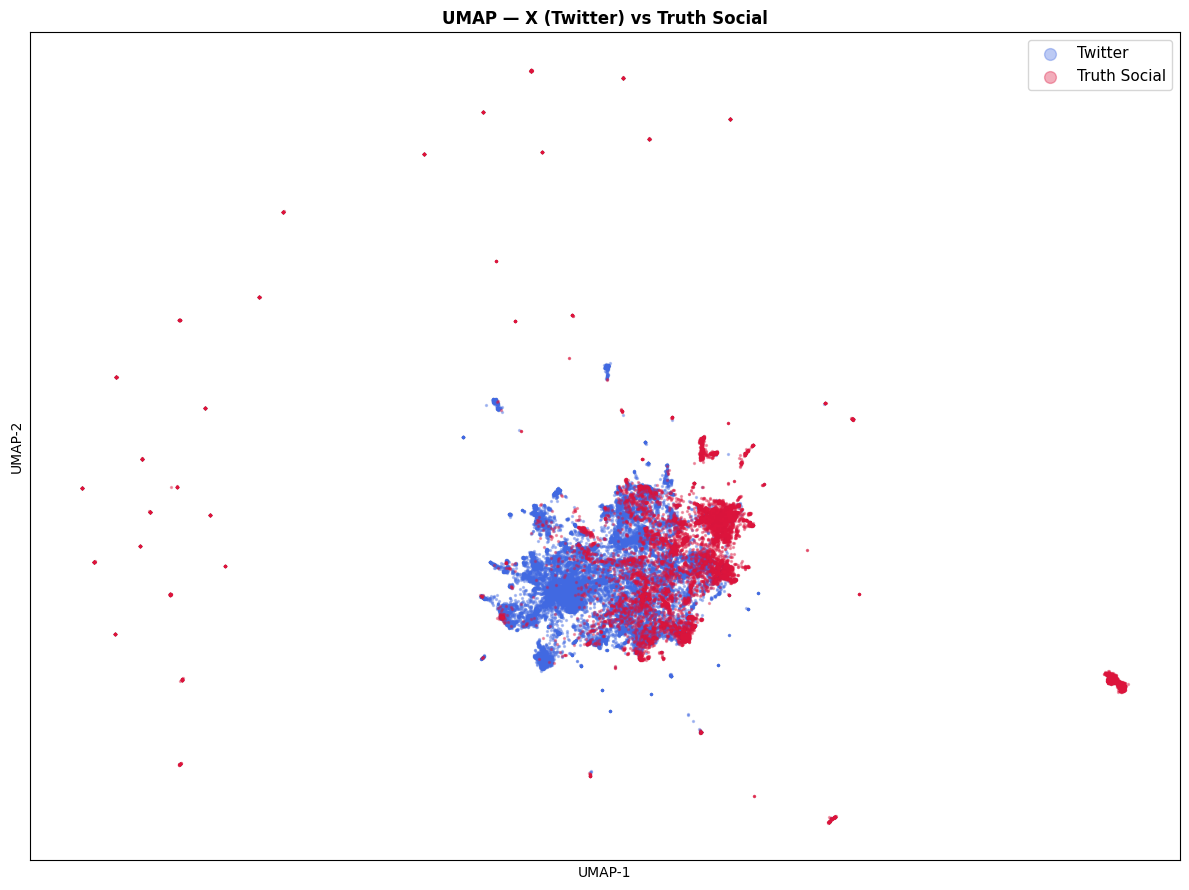

In [ ]:
# Plot 3 — X vs Truth Social
if "platform" in originals.columns:
    plot_df3 = originals.sample(min(N_UMAP_PLOT, len(originals)), random_state=42)
    pal = {"Twitter": "royalblue", "Truth Social": "crimson"}
    fig, ax = plt.subplots(figsize=(12, 9))
    for p in plot_df3["platform"].unique():
        sub = plot_df3[plot_df3["platform"] == p]
        ax.scatter(sub["umap_x"], sub["umap_y"], s=2, alpha=0.35,
                   label=p, color=pal.get(p, "grey"), rasterized=True)
    ax.legend(markerscale=6, fontsize=11)
    ax.set_title("UMAP — X (Twitter) vs Truth Social", fontweight="bold")
    ax.set(xlabel="UMAP-1", ylabel="UMAP-2"); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "umap_by_platform.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7 — Final Merge & Save

**Design choice:** tweet features on day `t` are matched to *next-day* (`t+1`) market
returns via the pre-shifted `next_log_return` column. This avoids look-ahead bias.

Three output files:
- `tweets_features.pkl` — one row per tweet, all features
- `daily_features.csv` — one row per day, aggregated tweet features
- `feature_matrix.csv` — one row per trading day, model-ready (daily + market)

In [ ]:
# Embedding metadata to add to the daily feature matrix
emb_meta = daily_embeddings[["date_only", "emb_diversity",
                              "dominant_cluster", "novelty_score"]].copy()
cluster_dummies = pd.get_dummies(emb_meta["dominant_cluster"], prefix="cluster")
emb_meta = pd.concat([emb_meta, cluster_dummies], axis=1)

# Merge: market data + daily tweet features + embedding metadata
feature_matrix = (
    sp
    .merge(daily_features, on="date_only", how="left")
    .merge(emb_meta,       on="date_only", how="left")
    .dropna(subset=["vader_mean"])   # drop days with no tweet data
)

print("Feature matrix shape:", feature_matrix.shape)
print("\nMissing values (>5%):")
null_pct = feature_matrix.isnull().mean().sort_values(ascending=False)
print(null_pct[null_pct > 0.05])
feature_matrix.head()

Feature matrix shape: (3526, 96)

Missing values (>5%):
vader_std_premarket                     0.4838
finbert_std_premarket                   0.4838
max_engagement_premarket                0.3267
mean_word_count_premarket               0.3267
topic_media_attacks_premarket           0.3267
topic_legal_premarket                   0.3267
vader_max_neg_premarket                 0.3267
topic_trump_identity_premarket          0.3267
topic_sports_premarket                  0.3267
topic_book_promotion_premarket          0.3267
topic_energy_environment_premarket      0.3267
topic_rallies_nationalism_premarket     0.3267
topic_trade_geopolitics_premarket       0.3267
topic_economy_markets_premarket         0.3267
topic_motivational_business_premarket   0.3267
topic_endorsements_premarket            0.3267
topic_elections_premarket               0.3267
topic_rallies_campaign_premarket        0.3267
mention_count_premarket                 0.3267
vader_max_pos_premarket                 0.3267
finb

,date,Close,High,Low,Open,Volume,log_return,abs_return,intraday_range,next_log_return,market_up,next_market_up,return_lag1,return_lag2,vol_5d,vol_20d,date_only,post_count,vader_mean,vader_std,vader_max_pos,vader_max_neg,finbert_mean,finbert_std,caps_ratio_mean,exclamation_mean,exclamation_max,max_engagement,mean_word_count,mention_count,reply_count,topic_elections,topic_rallies_campaign,topic_praise_thanks,topic_motivational,topic_media_attacks,topic_legal,topic_trump_identity,topic_rallies_nationalism,topic_trade_geopolitics,topic_economy_markets,topic_motivational_business,topic_endorsements,topic_sports,topic_book_promotion,topic_energy_environment,post_count_premarket,vader_mean_premarket,vader_std_premarket,vader_max_pos_premarket,vader_max_neg_premarket,finbert_mean_premarket,finbert_std_premarket,caps_ratio_mean_premarket,exclamation_mean_premarket,exclamation_max_premarket,max_engagement_premarket,mean_word_count_premarket,mention_count_premarket,reply_count_premarket,topic_elections_premarket,topic_rallies_campaign_premarket,topic_praise_thanks_premarket,topic_motivational_premarket,topic_media_attacks_premarket,topic_legal_premarket,topic_trump_identity_premarket,topic_rallies_nationalism_premarket,topic_trade_geopolitics_premarket,topic_economy_markets_premarket,topic_motivational_business_premarket,topic_endorsements_premarket,topic_sports_premarket,topic_book_promotion_premarket,topic_energy_environment_premarket,vader_3d_rolling,vader_7d_rolling,vader_momentum,emb_diversity,dominant_cluster,novelty_score,cluster_outlier,cluster_topic_0,cluster_topic_1,cluster_topic_10,cluster_topic_11,cluster_topic_12,cluster_topic_13,cluster_topic_2,cluster_topic_3,cluster_topic_4,cluster_topic_5,cluster_topic_6,cluster_topic_7,cluster_topic_8,cluster_topic_9
0,2009-05-04,907.2400,907.8500,879.2100,879.2100,7038840000,0.0339,0.0339,0.0326,-0.0038,1,0,NaN,NaN,NaN,NaN,2009-05-04,2.0000,0.6483,0.1737,0.7712,0.5255,0.0418,0.0046,0.0991,1.0000,1.0000,7.2786,22.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6483,0.6483,0.0000,0.0200,outlier,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2009-05-08,929.2300,930.1700,909.0300,909.0300,8163280000,0.0241,0.0241,0.0233,-0.0215,1,0,-0.0132,0.0174,0.0196,NaN,2009-05-08,2.0000,0.3234,0.4574,0.6468,0.0000,0.0508,0.0177,0.1200,0.5000,1.0000,3.8918,15.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.6468,NaN,0.6468,0.6468,0.0383,NaN,0.1196,1.0000,1.0000,3.8918,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4859,0.4859,-0.1625,0.0219,outlier,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,2009-05-12,908.3500,915.5700,896.4600,910.5200,6871750000,-0.0010,0.0010,0.0210,-0.0269,0,0,-0.0215,0.0241,0.0195,NaN,2009-05-12,2.0000,0.2404,0.3400,0.4809,0.0000,-0.1093,0.1675,0.0847,0.0000,0.0000,8.0864,20.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4041,0.4041,-0.1636,0.0249,outlier,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,2009-05-13,883.9200,905.4000,882.8000,905.4000,7091820000,-0.0269,0.0269,0.0250,0.0104,0,1,-0.0010,-0.0215,0.0203,NaN,2009-05-13,1.0000,0.7506,NaN,0.7506,0.7506,0.0848,NaN,0.0778,0.0000,0.0000,3.4657,16.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
# Tweet-level (pkl preserves list columns and dtypes)
originals.drop(columns=["emb_idx"], errors="ignore").to_pickle(
    OUTPUT_DIR / "tweets_features.pkl"
)

# Daily features
daily_features_full = daily_features.merge(
    daily_embeddings[["date_only", "emb_diversity", "dominant_cluster", "novelty_score"]],
    on="date_only", how="left"
)
daily_features_full.to_csv(OUTPUT_DIR / "daily_features.csv", index=False)

# Model-ready matrix
feature_matrix.to_csv(OUTPUT_DIR / "feature_matrix.csv", index=False)

# Raw embedding matrices (numpy is the right format for large float arrays)
np.save(OUTPUT_DIR / "tweet_embeddings.npy",      embeddings.astype(np.float32))
np.save(OUTPUT_DIR / "daily_mean_embeddings.npy", emb_matrix.astype(np.float32))
daily_embeddings[["date_only"]].to_csv(
    OUTPUT_DIR / "daily_mean_embeddings_dates.csv", index=False
)

print("Saved to:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:<45}  {f.stat().st_size/1e6:>6.1f} MB")

Saved to: c:\Dev\nlp-final-project\3_feature_engineering\features
  bertopic_keywords.png                             0.2 MB
  bertopic_model                                  463.9 MB
  bertopic_topics.csv                               0.0 MB
  cluster_selection.png                             0.1 MB
  daily_features.csv                                2.2 MB
  daily_mean_embeddings.npy                         7.5 MB
  daily_mean_embeddings_dates.csv                   0.1 MB
  daily_premarket_embeddings.npy                    4.9 MB
  feature_matrix.csv                                2.8 MB
  novelty_over_time.png                             0.2 MB
  tweet_embeddings.npy                            114.8 MB
  tweets_features.pkl                              92.3 MB
  umap_2d.npy                                       0.6 MB
  umap_by_cluster.png                               0.2 MB
  umap_by_platform.png                              0.2 MB
  umap_by_return.png                             